**UTS ANALISIS DATA TIDAK TERSTRUKTUR**

*Text Analytics: Text Classification (Supervised)*



*   Nama    : Manda Liya Andini
*   NPM     : 2306262415
*   Kelas   : B

## Install Library

In [13]:
!pip install Sastrawi
!pip install wordcloud

## Import Library

In [14]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

# Sastrawi - NLP Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## Load Dataset

In [15]:
df_path = '/content/tiketcom_reviews_labeled.csv'

df = pd.read_csv(df_path)

print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')

Shape: (72852, 12)
Kolom: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion', 'labels']


## EDA

### Normalisasi Label & Proporsi Variabel Target

In [16]:
df['sentiment'] = df['labels'].str.lower().str.strip()

print("Distribusi sentimen:")
print(df['sentiment'].value_counts())
print()
for label, count in df['sentiment'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label:10s}: {count:6,} ({pct:.1f}%)")

Distribusi sentimen:
sentiment
positif    47736
negatif    20053
netral      5063
Name: count, dtype: int64

  positif   : 47,736 (65.5%)
  negatif   : 20,053 (27.5%)
  netral    :  5,063 (6.9%)


### Rentang Waktu & Statistik Dataset

In [17]:
df['at'] = pd.to_datetime(df['at'])
df['content_len'] = df['content'].fillna('').astype(str).apply(len)

print(f"Rentang Waktu Ulasan:")
print(f"  Awal : {df['at'].min().strftime('%d %B %Y')}")
print(f"  Akhir: {df['at'].max().strftime('%d %B %Y')}")
print(f"\nStatistik Panjang Teks (karakter):")
print(f"  Mean   : {df['content_len'].mean():.1f}")
print(f"  Median : {df['content_len'].median():.1f}")
print(f"  Min    : {df['content_len'].min()}")
print(f"  Max    : {df['content_len'].max()}")
print(f"\nMissing values (content): {df['content'].isnull().sum()}")

Rentang Waktu Ulasan:
  Awal : 09 June 2014
  Akhir: 27 January 2026

Statistik Panjang Teks (karakter):
  Mean   : 32.0
  Median : 12.0
  Min    : 0
  Max    : 903

Missing values (content): 3


### Chart Proporsi Sentimen

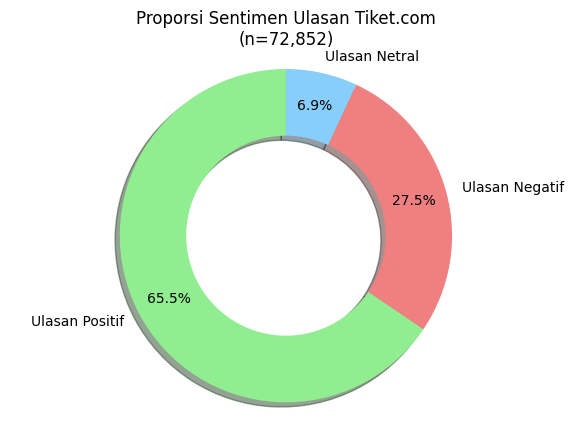

Plot 1 tersimpan: plot_01_proporsi_sentimen.png


In [18]:
def donut(sizes, ax, angle=90, labels=None,
          colors=None, explode=None, shadow=None):
    ax.pie(sizes, colors=colors, labels=labels,
           autopct='%.1f%%', startangle=angle,
           pctdistance=0.8, explode=explode,
           wedgeprops=dict(width=0.4), shadow=shadow)
    plt.axis('equal')
    plt.tight_layout()

sizes   = df['sentiment'].value_counts()
labels  = ['Ulasan Positif', 'Ulasan Negatif', 'Ulasan Netral']
colors  = ['lightgreen', 'lightcoral', 'lightskyblue']
explode = (0, 0, 0)

f, ax = plt.subplots(figsize=(6, 4))
donut(sizes, ax, 90, labels, colors=colors,
      explode=explode, shadow=True)
ax.set_title(
    "Proporsi Sentimen Ulasan Tiket.com\n"
    f"(n={len(df):,})"
)
plt.savefig('plot_01_proporsi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 tersimpan: plot_01_proporsi_sentimen.png")

### Hapus Baris dengan Content Kosong

In [19]:
# Terdapat 3 baris dengan content kosong (missing values)
# Baris ini dihapus karena tidak dapat diproses dalam pipeline NLP

df.dropna(subset=['content'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Data setelah hapus missing content: {len(df):,} baris")
print(df['sentiment'].value_counts())

Data setelah hapus missing content: 72,849 baris
sentiment
positif    47736
negatif    20050
netral      5063
Name: count, dtype: int64


## Pre-Processing

### Pre-Processing Tahap 1: Case Folding & Data Cleaning

In [20]:
def clean_review(text):
    """
    Tahap 1 preprocessing:
    1. Case folding: ubah ke huruf kecil
    2. Hapus baris baru
    3. Hapus URL
    4. Hapus mention (@) dan hashtag (#)
    5. Hapus angka
    6. Hapus tanda baca dan karakter non-alfabet
    7. Normalisasi spasi
    """
    text = str(text)
    # 1. Case folding
    text = text.lower()
    # 2. Hapus baris baru
    text = re.sub(r'\n', ' ', text)
    # 3. Hapus URL
    text = re.sub(
        r'(https?:\/\/(?:www\.|(?!www))[a-zA-Z0-9]'
        r'[a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,}|'
        r'www\.[a-zA-Z0-9][a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,})',
        ' ', text
    )
    # 4. Hapus mention dan hashtag
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    # 5. Hapus angka
    text = re.sub(r'\d+', ' ', text)
    # 6. Hapus tanda baca
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'[_]', ' ', text)
    # 7. Normalisasi spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_v1(df):
    df_pp = df.copy()
    df_pp['review_text'] = df_pp['content'].map(clean_review)
    df_pp['review_text'].replace('', np.nan, inplace=True)
    df_pp['review_text'].replace(' ', np.nan, inplace=True)
    df_pp.dropna(subset=['review_text'], inplace=True)
    return df_pp

df_v1 = preprocess_v1(df)
print(f"Setelah Preprocessing Tahap 1: {df_v1.shape[0]:,} baris")

print("\nContoh hasil Case Folding & Cleaning:")
for i in range(3):
    row = df.iloc[i]
    print(f"\n  [{row['sentiment'].upper()}]")
    print(f"  Original : {str(row['content'])[:85]}")
    print(f"  Cleaned  : {df_v1['review_text'].iloc[i][:85]}")

Setelah Preprocessing Tahap 1: 71,443 baris

Contoh hasil Case Folding & Cleaning:

  [NEGATIF]
  Original : Saya sudah melakukan pembayaran untuk penerbangan Banda Aceh-Jakarta 18 Mei 
2018, ta
  Cleaned  : saya sudah melakukan pembayaran untuk penerbangan banda aceh jakarta mei tapi kode bo

  [NEGATIF]
  Original : Promo ngga jelas.. Jam 3 mulai promo, pas pake promo kartu jam 3.15 uda ngga bisa dip
  Cleaned  : promo ngga jelas jam mulai promo pas pake promo kartu jam uda ngga bisa dipake dibila

  [POSITIF]
  Original : Baik
  Cleaned  : baik


### Pre-Processing Tahap 2: Tokenisasi & Stopword Removal

In [21]:
sw_factory    = StopWordRemoverFactory()
sastrawi_stop = sw_factory.get_stop_words()

# Stopword tambahan konteks ulasan aplikasi travel/tiket online
custom_stop = [
    # Nama aplikasi & entitas
    'tiket', 'com', 'tiketcom', 'app', 'apk', 'aplikasi',
    # Kata informal / slang
    'nya', 'ga', 'gak', 'nggak', 'engga', 'enggak',
    'aja', 'deh', 'sih', 'dong', 'nih', 'loh', 'lah',
    'udah', 'udh', 'sdh', 'blm',
    # Sapaan
    'min', 'bang', 'kak', 'mas', 'bu', 'pak', 'bro', 'sis',
    # Kata umum tidak bermakna
    'ok', 'oke', 'good', 'nice', 'great',
    'mohon', 'tolong', 'halo', 'hai',
    'juga', 'saja', 'banget', 'bgt', 'bngt', 'sekali',
]

list_stopwords = set(sastrawi_stop + custom_stop)
print(f"Total stopword: {len(list_stopwords)} kata")

def normalize_review(text):
    """
    Tahap 2 preprocessing:
    1. Tokenisasi dengan NLTK word_tokenize
    2. Hapus token yang termasuk stopword
    3. Hapus token pendek (<= 2 karakter)
    4. Gabung kembali menjadi string
    """
    list_text = word_tokenize(text)
    list_text = [
        w for w in list_text
        if w not in list_stopwords and len(w) > 2
    ]
    text = ' '.join(list_text)
    return text

def preprocess_v2(df):
    df_pp = df.copy()
    df_pp['review_text'] = df_pp['review_text'].map(normalize_review)
    df_pp['review_text'].replace('', np.nan, inplace=True)
    df_pp['review_text'].replace(' ', np.nan, inplace=True)
    df_pp.dropna(subset=['review_text'], inplace=True)
    return df_pp

df_v2 = preprocess_v2(df_v1)
print(f"\nSetelah Preprocessing Tahap 2: {df_v2.shape[0]:,} baris")

print("\nContoh hasil Tokenisasi & Stopword Removal:")
for i in range(3):
    print(f"\n  [{df_v1['sentiment'].iloc[i].upper()}]")
    print(f"  Sebelum : {df_v1['review_text'].iloc[i][:85]}")
    print(f"  Sesudah : {df_v2['review_text'].iloc[i][:85]}")

Total stopword: 164 kata

Setelah Preprocessing Tahap 2: 60,082 baris

Contoh hasil Tokenisasi & Stopword Removal:

  [NEGATIF]
  Sebelum : saya sudah melakukan pembayaran untuk penerbangan banda aceh jakarta mei tapi kode bo
  Sesudah : melakukan pembayaran penerbangan banda aceh jakarta mei kode booking diterima bantuan

  [NEGATIF]
  Sebelum : promo ngga jelas jam mulai promo pas pake promo kartu jam uda ngga bisa dipake dibila
  Sesudah : promo ngga jelas jam mulai promo pas pake promo kartu jam uda ngga dipake dibilang ud

  [POSITIF]
  Sebelum : baik
  Sesudah : baik


### Pre-Processing Tahap 3: Stemming

In [22]:
stem_factory = StemmerFactory()
stemmer      = stem_factory.create_stemmer()

print("Proses stemming sedang berjalan...")

def stem_review(text):
    return stemmer.stem(text)

def preprocess_v3(df):
    df_pp = df.copy()
    df_pp['review_text'] = df_pp['review_text'].map(stem_review)
    df_pp['review_text'].replace('', np.nan, inplace=True)
    df_pp['review_text'].replace(' ', np.nan, inplace=True)
    df_pp.dropna(subset=['review_text'], inplace=True)
    return df_pp

df_v3 = preprocess_v3(df_v2)

print(f"\nStemming selesai!")
print(f"Data final setelah full preprocessing: {df_v3.shape[0]:,} baris")
print(f"\nDistribusi akhir:")
print(df_v3['sentiment'].value_counts())

print("\nContoh hasil Stemming:")
for i in range(3):
    print(f"\n  [{df_v2['sentiment'].iloc[i].upper()}]")
    print(f"  Sebelum : {df_v2['review_text'].iloc[i][:85]}")
    print(f"  Sesudah : {df_v3['review_text'].iloc[i][:85]}")

Proses stemming sedang berjalan...

Stemming selesai!
Data final setelah full preprocessing: 60,060 baris

Distribusi akhir:
sentiment
positif    40915
negatif    18191
netral       954
Name: count, dtype: int64

Contoh hasil Stemming:

  [NEGATIF]
  Sebelum : melakukan pembayaran penerbangan banda aceh jakarta mei kode booking diterima bantuan
  Sesudah : laku bayar terbang banda aceh jakarta mei kode booking terima bantu terima kasih

  [NEGATIF]
  Sebelum : promo ngga jelas jam mulai promo pas pake promo kartu jam uda ngga dipake dibilang ud
  Sesudah : promo ngga jelas jam mulai promo pas pake promo kartu jam uda ngga dipake bilang uda 

  [POSITIF]
  Sebelum : baik
  Sesudah : baik


## Corpus & Analisis Frekuensi Kata

In [23]:
def make_corpus(column):
    corpus_list = []
    for text in column:
        corpus_list.extend(str(text).split(' '))
    corpus = ' '.join(corpus_list)
    corpus = re.sub('[ ]+', ' ', corpus)
    return corpus

corpus_neg = make_corpus(
    df_v3[df_v3['sentiment'] == 'negatif']['review_text']
)
corpus_net = make_corpus(
    df_v3[df_v3['sentiment'] == 'netral']['review_text']
)
corpus_pos = make_corpus(
    df_v3[df_v3['sentiment'] == 'positif']['review_text']
)
corpus_all = make_corpus(df_v3['review_text'])

corpus_set = set(corpus_all.split(' '))
print(f"Jumlah kata unik dalam corpus: {len(corpus_set):,}")

Jumlah kata unik dalam corpus: 17,316


## WordCloud per Kelas Sentimen

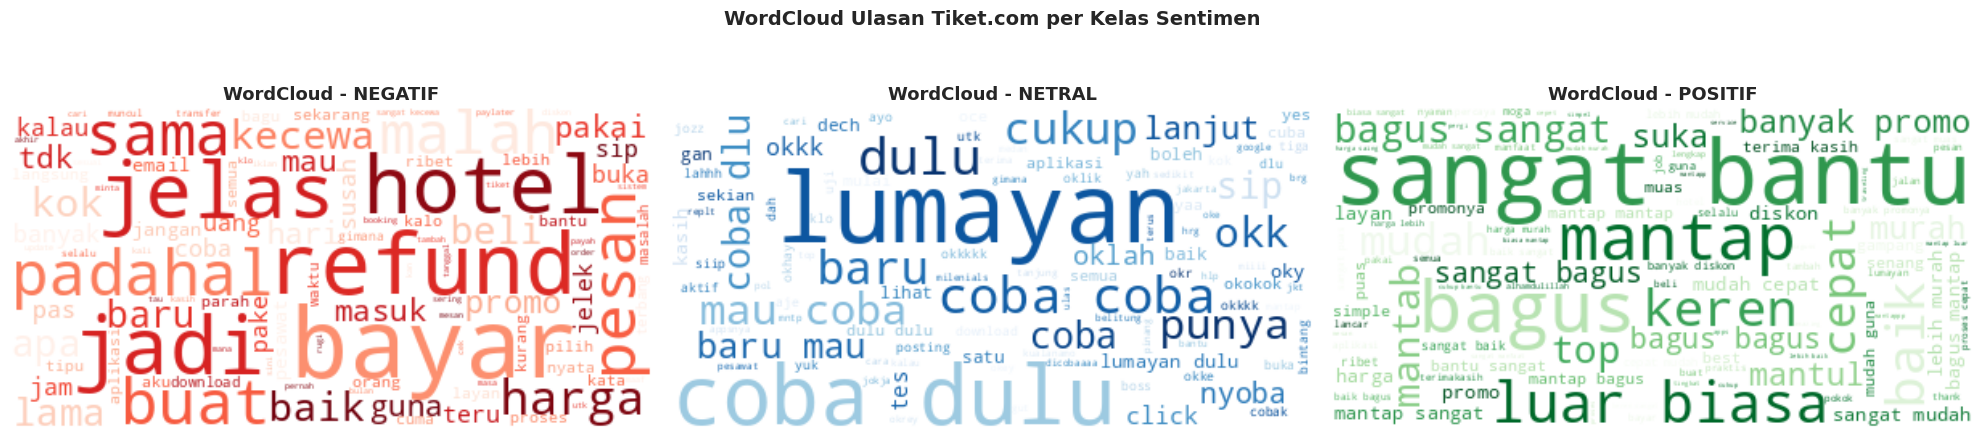

Plot 2 tersimpan: plot_02_wordcloud.png


In [24]:
plt.style.use('default')
sns.set(style='ticks', palette='Set2')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (corpus, cmap, title) in zip(axes, [
    (corpus_neg, 'Reds',    'WordCloud - NEGATIF'),
    (corpus_net, 'Blues',   'WordCloud - NETRAL'),
    (corpus_pos, 'Greens',  'WordCloud - POSITIF'),
]):
    if corpus.strip():
        wc = WordCloud(
            max_font_size=60, max_words=100,
            background_color='white', colormap=cmap
        ).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle(
    "WordCloud Ulasan Tiket.com per Kelas Sentimen",
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot_02_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 tersimpan: plot_02_wordcloud.png")

## Frekuensi Kata (Top 20 per Kelas)

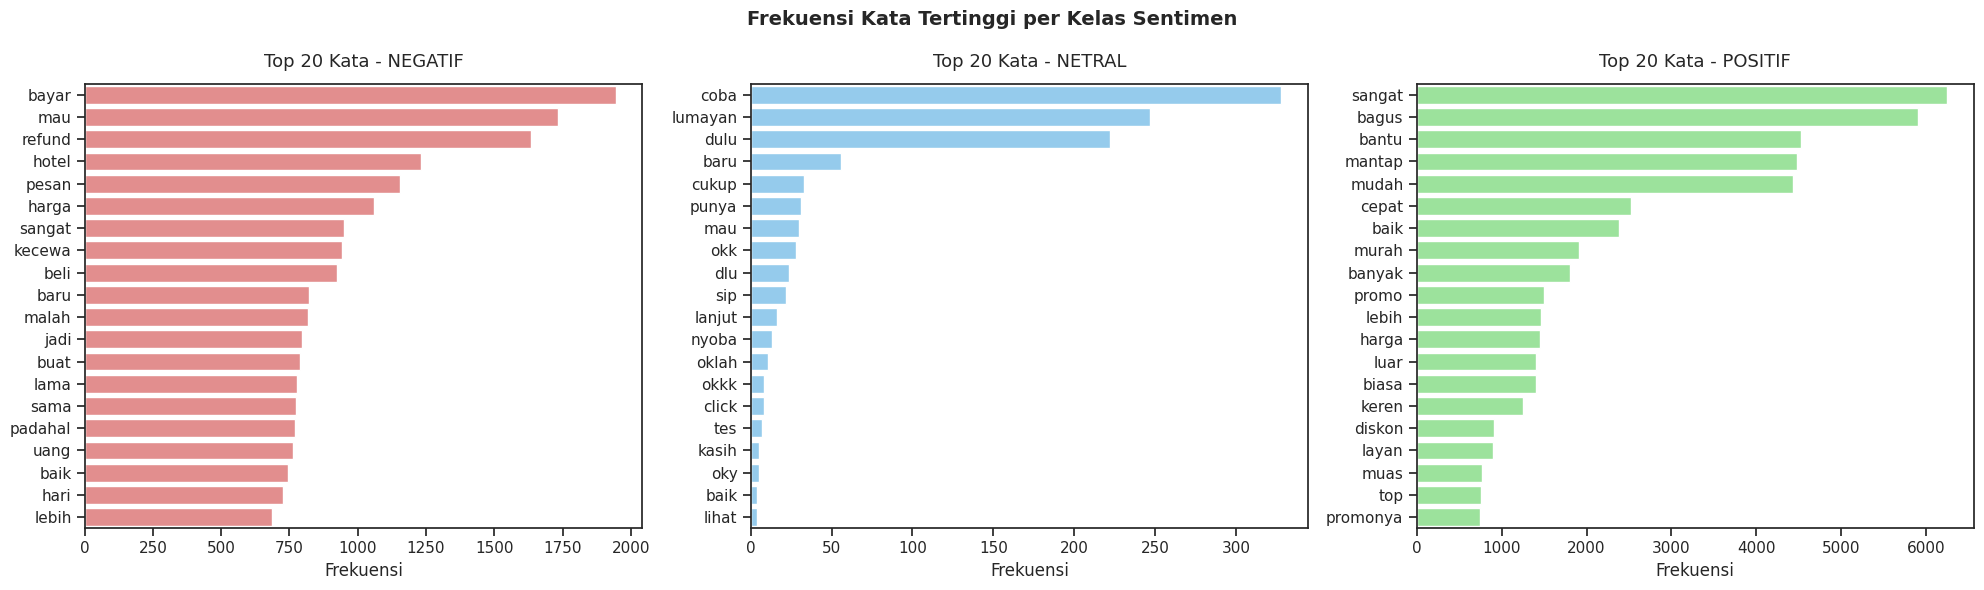

Plot 3 tersimpan: plot_03_word_freq.png


In [25]:
def word_freq(corpus, top=20):
    tokenized = word_tokenize(corpus)
    freqdist  = FreqDist(tokenized)
    freqdist  = freqdist.most_common(top)
    label     = [tup[0] for tup in freqdist]
    freq      = [tup[1] for tup in freqdist]
    return pd.DataFrame({'word': label, 'freq': freq})

freq_neg = word_freq(corpus_neg, top=20)
freq_net = word_freq(corpus_net, top=20)
freq_pos = word_freq(corpus_pos, top=20)

mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.titlepad']  = 12

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x='freq', y='word', data=freq_neg,
            color='lightcoral', ax=ax1)
ax1.set_title('Top 20 Kata - NEGATIF')
ax1.set_xlabel('Frekuensi')
ax1.set_ylabel('')

sns.barplot(x='freq', y='word', data=freq_net,
            color='lightskyblue', ax=ax2)
ax2.set_title('Top 20 Kata - NETRAL')
ax2.set_xlabel('Frekuensi')
ax2.set_ylabel('')

sns.barplot(x='freq', y='word', data=freq_pos,
            color='lightgreen', ax=ax3)
ax3.set_title('Top 20 Kata - POSITIF')
ax3.set_xlabel('Frekuensi')
ax3.set_ylabel('')

plt.suptitle(
    'Frekuensi Kata Tertinggi per Kelas Sentimen',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot_03_word_freq.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 tersimpan: plot_03_word_freq.png")

## Splitting

In [29]:
# Label encoding
label_map    = {'negatif': 0, 'netral': 1, 'positif': 2}
label_decode = {0: 'negatif', 1: 'netral', 2: 'positif'}

train_set, val_set = train_test_split(
    df_v3,
    test_size=0.3,
    stratify=df_v3['sentiment'],
    random_state=42
)
val_set, test_set = train_test_split(
    val_set,
    test_size=0.33,
    stratify=val_set['sentiment'],
    random_state=42
)

print(f"Train shape : {train_set.shape}")
print(f"Val shape   : {val_set.shape}")
print(f"Test shape  : {test_set.shape}")

print(f"\nDistribusi Train:")
for label, count in train_set['sentiment'].value_counts().items():
    pct = count/len(train_set)*100
    print(f"  {label:10s}: {count:,} ({pct:.1f}%)")

# Simpan hasil split (opsional)
train_set.to_csv('train_set.csv', index=False)
val_set.to_csv('val_set.csv', index=False)
test_set.to_csv('test_set.csv', index=False)
print("\nData split tersimpan.")

Train shape : (42042, 15)
Val shape   : (12072, 15)
Test shape  : (5946, 15)

Distribusi Train:
  positif   : 28,640 (68.1%)
  negatif   : 12,734 (30.3%)
  netral    : 668 (1.6%)

Data split tersimpan.


## Modeling

### TF-IDF Vectorization

In [30]:

X_train = train_set['review_text']
y_train = train_set['sentiment'].map(label_map)

X_val   = val_set['review_text']
y_val   = val_set['sentiment'].map(label_map)

X_test  = test_set['review_text']
y_test  = test_set['sentiment'].map(label_map)

# TF-IDF Vectorizer
# max_features=10000 : 10.000 fitur TF-IDF tertinggi
# ngram_range=(1,2)  : unigram dan bigram
# min_df=3           : abaikan term yang muncul < 3 dokumen
# sublinear_tf=True  : log normalization

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Dimensi TF-IDF:")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Val   : {X_val_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")

Dimensi TF-IDF:
  Train : (42042, 9916)
  Val   : (12072, 9916)
  Test  : (5946, 9916)


### Model 1: Multinomial Naive Bayes

In [31]:
print("=" * 52)
print("MODEL 1: MULTINOMIAL NAIVE BAYES")
print("=" * 52)

nb_model     = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

nb_val_pred  = nb_model.predict(X_val_tfidf)
nb_test_pred = nb_model.predict(X_test_tfidf)

print("\n--- Validation Set ---")
print(classification_report(
    y_val, nb_val_pred,
    target_names=['negatif', 'netral', 'positif']
))
print("--- Test Set ---")
print(classification_report(
    y_test, nb_test_pred,
    target_names=['negatif', 'netral', 'positif']
))

MODEL 1: MULTINOMIAL NAIVE BAYES

--- Validation Set ---
              precision    recall  f1-score   support

     negatif       0.91      0.81      0.85      3656
      netral       0.97      0.17      0.28       192
     positif       0.91      0.97      0.94      8224

    accuracy                           0.91     12072
   macro avg       0.93      0.65      0.69     12072
weighted avg       0.91      0.91      0.90     12072

--- Test Set ---
              precision    recall  f1-score   support

     negatif       0.91      0.80      0.85      1801
      netral       1.00      0.10      0.17        94
     positif       0.90      0.97      0.94      4051

    accuracy                           0.90      5946
   macro avg       0.94      0.62      0.65      5946
weighted avg       0.91      0.90      0.90      5946



### Model 2: Support Vector Machine (LinearSVC)

In [32]:
print("=" * 52)
print("MODEL 2: SUPPORT VECTOR MACHINE (LinearSVC)")
print("=" * 52)

svm_model     = LinearSVC(C=1.0, random_state=42, max_iter=3000)
svm_model.fit(X_train_tfidf, y_train)

svm_val_pred  = svm_model.predict(X_val_tfidf)
svm_test_pred = svm_model.predict(X_test_tfidf)

print("\n--- Validation Set ---")
print(classification_report(
    y_val, svm_val_pred,
    target_names=['negatif', 'netral', 'positif']
))
print("--- Test Set ---")
print(classification_report(
    y_test, svm_test_pred,
    target_names=['negatif', 'netral', 'positif']
))

MODEL 2: SUPPORT VECTOR MACHINE (LinearSVC)

--- Validation Set ---
              precision    recall  f1-score   support

     negatif       0.86      0.91      0.88      3656
      netral       0.75      0.81      0.78       192
     positif       0.96      0.94      0.95      8224

    accuracy                           0.92     12072
   macro avg       0.86      0.88      0.87     12072
weighted avg       0.93      0.92      0.93     12072

--- Test Set ---
              precision    recall  f1-score   support

     negatif       0.86      0.90      0.88      1801
      netral       0.82      0.78      0.80        94
     positif       0.95      0.94      0.94      4051

    accuracy                           0.92      5946
   macro avg       0.88      0.87      0.87      5946
weighted avg       0.92      0.92      0.92      5946



### Model 3: Random Forest

In [33]:
print("=" * 52)
print("MODEL 3: RANDOM FOREST")
print("=" * 52)

rf_model     = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)

rf_val_pred  = rf_model.predict(X_val_tfidf)
rf_test_pred = rf_model.predict(X_test_tfidf)

print("\n--- Validation Set ---")
print(classification_report(
    y_val, rf_val_pred,
    target_names=['negatif', 'netral', 'positif']
))
print("--- Test Set ---")
print(classification_report(
    y_test, rf_test_pred,
    target_names=['negatif', 'netral', 'positif']
))

MODEL 3: RANDOM FOREST

--- Validation Set ---
              precision    recall  f1-score   support

     negatif       0.85      0.91      0.88      3656
      netral       0.78      0.79      0.78       192
     positif       0.96      0.93      0.95      8224

    accuracy                           0.92     12072
   macro avg       0.86      0.88      0.87     12072
weighted avg       0.92      0.92      0.92     12072

--- Test Set ---
              precision    recall  f1-score   support

     negatif       0.85      0.90      0.88      1801
      netral       0.88      0.77      0.82        94
     positif       0.96      0.93      0.95      4051

    accuracy                           0.92      5946
   macro avg       0.90      0.87      0.88      5946
weighted avg       0.92      0.92      0.92      5946



## Evaluasi

### Confusion Matrix Ketiga Model

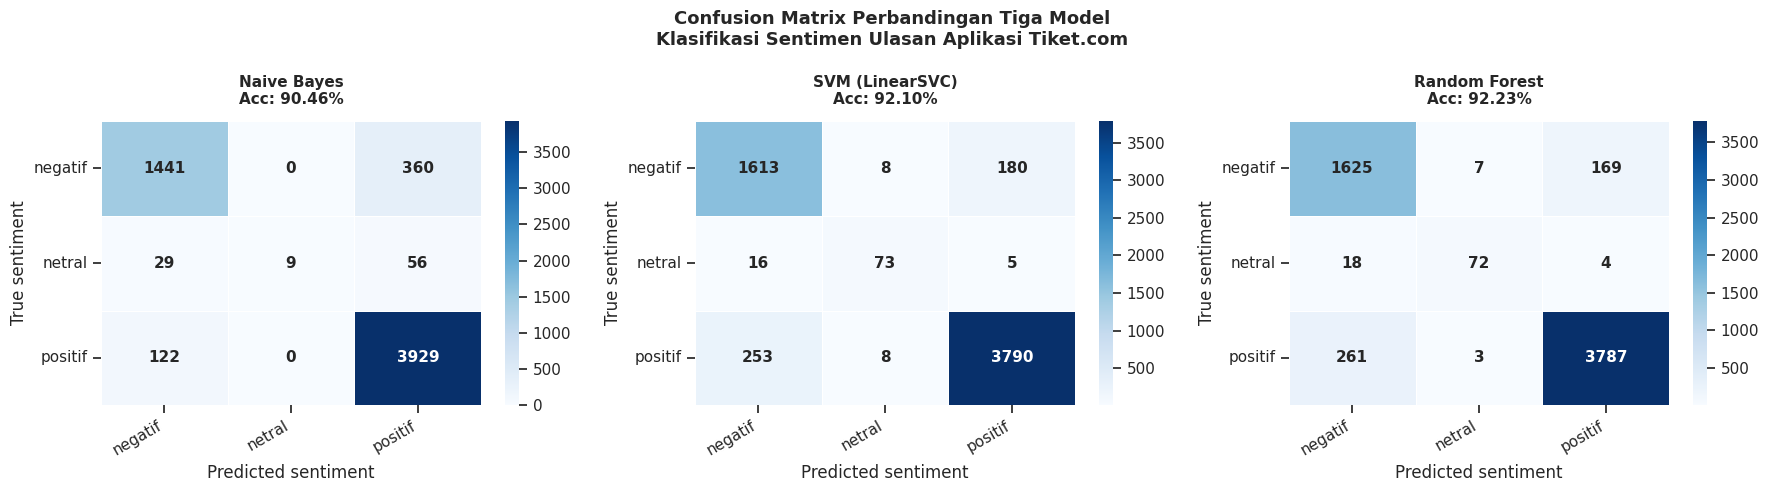

Plot 4 tersimpan: plot_04_confusion_matrix.png


In [34]:
label_names = ['negatif', 'netral', 'positif']

def show_confusion_matrix(cm, title, ax):
    df_cm = pd.DataFrame(
        cm,
        index=label_names,
        columns=label_names
    )
    hmap = sns.heatmap(
        df_cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        linewidths=0.5,
        annot_kws={'size': 11, 'weight': 'bold'}
    )
    hmap.yaxis.set_ticklabels(
        hmap.yaxis.get_ticklabels(), rotation=0, ha='right'
    )
    hmap.xaxis.set_ticklabels(
        hmap.xaxis.get_ticklabels(), rotation=30, ha='right'
    )
    ax.set_ylabel('True sentiment')
    ax.set_xlabel('Predicted sentiment')
    ax.set_title(title, fontsize=11, fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

show_confusion_matrix(
    confusion_matrix(y_test, nb_test_pred),
    f'Naive Bayes\n'
    f'Acc: {accuracy_score(y_test, nb_test_pred)*100:.2f}%',
    axes[0]
)
show_confusion_matrix(
    confusion_matrix(y_test, svm_test_pred),
    f'SVM (LinearSVC)\n'
    f'Acc: {accuracy_score(y_test, svm_test_pred)*100:.2f}%',
    axes[1]
)
show_confusion_matrix(
    confusion_matrix(y_test, rf_test_pred),
    f'Random Forest\n'
    f'Acc: {accuracy_score(y_test, rf_test_pred)*100:.2f}%',
    axes[2]
)

plt.suptitle(
    "Confusion Matrix Perbandingan Tiga Model\n"
    "Klasifikasi Sentimen Ulasan Aplikasi Tiket.com",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot_04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 tersimpan: plot_04_confusion_matrix.png")

### Classification Report & Tabel Perbandingan

PERBANDINGAN PERFORMA KETIGA MODEL (Test Set)
        Model  Accuracy  Precision  Recall  F1-Score
  Naive Bayes    0.9046     0.9060  0.9046    0.8977
          SVM    0.9210     0.9222  0.9210    0.9214
Random Forest    0.9223     0.9239  0.9223    0.9228


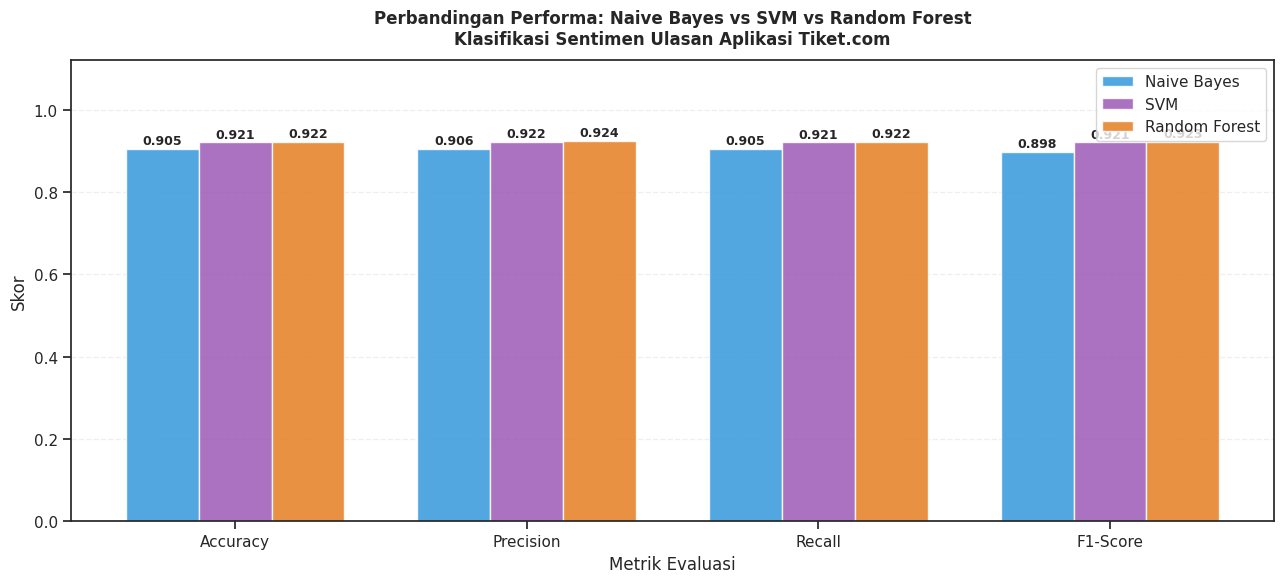

Plot 5 tersimpan: plot_05_perbandingan_model.png

Model Terbaik : Random Forest
F1-Score      : 0.9228
Accuracy      : 0.9223


In [35]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(
            y_true, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(
            y_true, y_pred, average='weighted'), 4),
        'F1-Score' : round(f1_score(
            y_true, y_pred, average='weighted'), 4),
    }

results = pd.DataFrame([
    get_metrics(y_test, nb_test_pred,  'Naive Bayes'),
    get_metrics(y_test, svm_test_pred, 'SVM'),
    get_metrics(y_test, rf_test_pred,  'Random Forest'),
])

print("=" * 62)
print("PERBANDINGAN PERFORMA KETIGA MODEL (Test Set)")
print("=" * 62)
print(results.to_string(index=False))

# Visualisasi perbandingan
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x      = np.arange(len(metrics_cols))
width  = 0.25
colors = ['#3498db', '#9b59b6', '#e67e22']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, color) in enumerate(
    zip(results['Model'], colors)
):
    vals = results[
        results['Model'] == model_name
    ][metrics_cols].values[0]
    bars = ax.bar(
        x + i*width, vals, width,
        label=model_name, color=color,
        alpha=0.85, edgecolor='white'
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title(
    "Perbandingan Performa: Naive Bayes vs SVM vs Random Forest\n"
    "Klasifikasi Sentimen Ulasan Aplikasi Tiket.com",
    fontsize=12, fontweight='bold'
)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('plot_05_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 tersimpan: plot_05_perbandingan_model.png")

best_idx   = results['F1-Score'].idxmax()
best_model = results.loc[best_idx, 'Model']
best_f1    = results.loc[best_idx, 'F1-Score']
best_acc   = results.loc[best_idx, 'Accuracy']
print(f"\nModel Terbaik : {best_model}")
print(f"F1-Score      : {best_f1:.4f}")
print(f"Accuracy      : {best_acc:.4f}")

### Uji Prediksi Manual (Inferensi)

In [36]:
def predict_sentiment(text, model, tfidf_vectorizer):
    """
    Prediksi sentimen teks baru menggunakan model terpilih.
    Pipeline: cleaning -> stopword removal -> stemming -> TF-IDF
    """
    cleaned = clean_review(text)
    cleaned = normalize_review(cleaned)
    cleaned = stemmer.stem(cleaned)
    vec     = tfidf_vectorizer.transform([cleaned])
    pred    = model.predict(vec)[0]
    return label_decode[pred]

test_sentences = [
    "Booking tiket pesawat sangat mudah dan cepat, harganya juga bersaing!",
    "Tiket sudah dibayar tapi tidak ada konfirmasi sama sekali, uang hilang.",
    "Aplikasinya lumayan, tampilan oke tapi kadang lambat saat loading.",
    "Refund sudah 2 minggu belum masuk, customer service tidak responsif.",
    "Promo flash sale-nya menarik, berhasil dapat tiket murah ke Bali!",
    "Tidak bisa login terus padahal akun benar, sangat mengecewakan.",
]

best_obj = {
    'Naive Bayes'  : nb_model,
    'SVM'          : svm_model,
    'Random Forest': rf_model
}[best_model]

print("=" * 60)
print(f"UJI PREDIKSI SENTIMEN - Model Terbaik: {best_model}")
print("=" * 60)
for text in test_sentences:
    pred = predict_sentiment(text, best_obj, tfidf)
    icons = {'positif': '[+]', 'negatif': '[-]', 'netral': '[~]'}
    print(f"\n{icons[pred]} {pred.upper()}")
    print(f"    {text}")

UJI PREDIKSI SENTIMEN - Model Terbaik: Random Forest

[+] POSITIF
    Booking tiket pesawat sangat mudah dan cepat, harganya juga bersaing!

[-] NEGATIF
    Tiket sudah dibayar tapi tidak ada konfirmasi sama sekali, uang hilang.

[-] NEGATIF
    Aplikasinya lumayan, tampilan oke tapi kadang lambat saat loading.

[-] NEGATIF
    Refund sudah 2 minggu belum masuk, customer service tidak responsif.

[+] POSITIF
    Promo flash sale-nya menarik, berhasil dapat tiket murah ke Bali!

[-] NEGATIF
    Tidak bisa login terus padahal akun benar, sangat mengecewakan.


### Ringkasan Akhir

In [38]:
print("\n" + "=" * 62)
print("RINGKASAN HASIL ANALISIS")
print("=" * 62)
print(f"Dataset      : Tiket.com App Sentiment Analysis Reviews")
print(f"Periode      : Juni 2014 - Januari 2026")
print(f"Total data   : {len(df_v3):,} ulasan (3 kelas)")
print(f"Kelas        : negatif / netral / positif")
print(f"Stopword     : Sastrawi built-in + custom = "
      f"{len(list_stopwords)} kata")
print(f"Split        : {len(train_set):,} train / "
      f"{len(val_set):,} val / {len(test_set):,} test")
print(f"TF-IDF       : max=10.000, ngram(1,2), sublinear_tf=True")
print(f"\n{results.to_string(index=False)}")
print(f"\nModel Terbaik : {best_model}")
print(f"F1-Score      : {best_f1:.4f}")
print(f"Accuracy      : {best_acc:.4f}")
print(f"\nPlot yang dihasilkan:")
for p in [
    "plot_01_proporsi_sentimen.png  -- Donut chart distribusi sentimen",
    "plot_02_wordcloud.png          -- WordCloud 3 kelas sentimen",
    "plot_03_word_freq.png          -- Top 20 kata per kelas",
    "plot_04_confusion_matrix.png   -- Confusion matrix 3 model",
    "plot_05_perbandingan_model.png -- Grafik perbandingan metrik",
]:
    print(f"  {p}")


RINGKASAN HASIL ANALISIS
Dataset      : Tiket.com App Sentiment Analysis Reviews
Periode      : Juni 2014 - Januari 2026
Total data   : 60,060 ulasan (3 kelas)
Kelas        : negatif / netral / positif
Stopword     : Sastrawi built-in + custom = 164 kata
Split        : 42,042 train / 12,072 val / 5,946 test
TF-IDF       : max=10.000, ngram(1,2), sublinear_tf=True

        Model  Accuracy  Precision  Recall  F1-Score
  Naive Bayes    0.9046     0.9060  0.9046    0.8977
          SVM    0.9210     0.9222  0.9210    0.9214
Random Forest    0.9223     0.9239  0.9223    0.9228

Model Terbaik : Random Forest
F1-Score      : 0.9228
Accuracy      : 0.9223

Plot yang dihasilkan:
  plot_01_proporsi_sentimen.png  -- Donut chart distribusi sentimen
  plot_02_wordcloud.png          -- WordCloud 3 kelas sentimen
  plot_03_word_freq.png          -- Top 20 kata per kelas
  plot_04_confusion_matrix.png   -- Confusion matrix 3 model
  plot_05_perbandingan_model.png -- Grafik perbandingan metrik
